In [30]:
# Artificial Neural Network


# Part 1 - Data Preprocessing

# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [35]:
# Importing the dataset
dataset = pd.read_csv('Churn_Modelling.csv')
X = dataset.iloc[:, 3:13]
y = dataset.iloc[:, 13]

In [36]:
#Create dummy variables
geography=pd.get_dummies(X["Geography"],drop_first=True)
gender=pd.get_dummies(X['Gender'],drop_first=True)

In [37]:
## Concatenate the Data Frames

X=pd.concat([X,geography,gender],axis=1)

In [38]:
## Drop Unnecessary columns
X=X.drop(['Geography','Gender'],axis=1)

In [39]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)


In [40]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [41]:
# Part 2 - Now let's make the ANN!

# Importing the Keras libraries and packages
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LeakyReLU,PReLU,ELU
from keras.layers import Dropout

In [42]:
# Initialising the ANN
classifier = Sequential()

In [43]:
# Adding the input layer and the first hidden layer
from keras.layers import Dense

classifier.add(Dense(units=6, kernel_initializer='he_uniform',
                     activation='relu', input_dim=11))


In [44]:
# Adding the second hidden layer
classifier.add(Dense(units=6, kernel_initializer='he_uniform', activation='relu'))

In [45]:
# Adding the output layer
classifier.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))


In [46]:
# Compiling the ANN
classifier.compile(optimizer = 'Adamax', loss = 'binary_crossentropy', metrics = ['accuracy'])


In [47]:
# Fitting the ANN to the Training set
model_history = classifier.fit(
    X_train, y_train,
    validation_split=0.33,
    batch_size=10,
    epochs=100
)

Epoch 1/100
536/536 [==============================] - 4s 4ms/step - loss: 0.8723 - accuracy: 0.4365 - val_loss: 0.6189 - val_accuracy: 0.6778
Epoch 2/100
536/536 [==============================] - 2s 4ms/step - loss: 0.5633 - accuracy: 0.7464 - val_loss: 0.5268 - val_accuracy: 0.7766
Epoch 3/100
536/536 [==============================] - 2s 4ms/step - loss: 0.5165 - accuracy: 0.7910 - val_loss: 0.5032 - val_accuracy: 0.7917
Epoch 4/100
536/536 [==============================] - 2s 3ms/step - loss: 0.4967 - accuracy: 0.7942 - val_loss: 0.4883 - val_accuracy: 0.7967
Epoch 5/100
536/536 [==============================] - 2s 4ms/step - loss: 0.4824 - accuracy: 0.7968 - val_loss: 0.4773 - val_accuracy: 0.7986
Epoch 6/100
536/536 [==============================] - 2s 3ms/step - loss: 0.4708 - accuracy: 0.8001 - val_loss: 0.4682 - val_accuracy: 0.8001
Epoch 7/100
536/536 [==============================] - 2s 3ms/step - loss: 0.4606 - accuracy: 0.8013 - val_loss: 0.4597 - val_accuracy: 0.8023

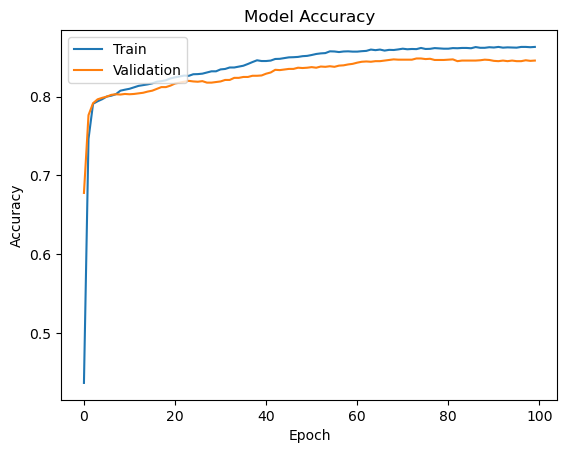

In [48]:
# list all data in history

plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


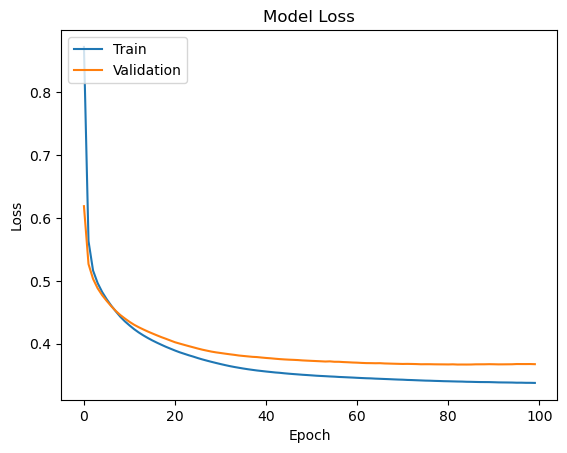

In [49]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [50]:
# Part 3 - Making the predictions and evaluating the model

# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 [==============================] - 0s 2ms/step


In [51]:

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1542,   53],
       [ 221,  184]], dtype=int64)

In [52]:
# Calculate the Accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
score

0.863